# Математическая статистика для анализа больших данных
## Семинар 5.
### Проверка гипотез. p-value

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

In [ ]:
# Bot check

# HW_ID: sbd_sem5
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as wg
from ipywidgets import interact, Layout
from IPython.display import display

sns.set(font_scale=1.5)

### Мощность критерия Вальда

Рассмотрим некоторое семейство распределений $\mathcal{P} = \{P_\theta\ |\ \theta \in \Theta\}$ и нулевую гипотезу $H_0: \theta = \theta_0$.

Известно, что для проверки такой гипотезы в случае выполнения ЦПТ для $P_\theta$ можно воспользоваться критерием Вальда. Однако при разных альтернативах используются разные виды критериев.

Напишем функции для вычисления мощности критериев Вальда разного вида.

In [2]:
def wald_power_two_sided(theta, theta0, n, sigma_est, alpha):
    """Вычисляет мощность для двусторонней альтернативы"""
    omega = np.sqrt(n) * (theta - theta0) / sigma_est
    return 1 - sps.norm.cdf(sps.norm.ppf(1 - alpha / 2) - omega) + \
               sps.norm.cdf(sps.norm.ppf(alpha / 2) - omega)

def wald_power_left_sided(theta, theta0, n, sigma_est, alpha):
    """Вычисляет мощность для левосторонней альтернативы"""
    omega = np.sqrt(n) * (theta - theta0) / sigma_est
    return sps.norm.cdf(sps.norm.ppf(alpha) - omega)

def wald_power_right_sided(theta, theta0, n, sigma_est, alpha):
    """Вычисляет мощность для правосторонней альтернативы"""
    omega = np.sqrt(n) * (theta - theta0) / sigma_est
    return sps.norm.sf(sps.norm.ppf(1 - alpha) - omega)

Зададим параметры в виде слайдеров и визуализируем на графике полученные мощности. Возможно для работы с виджетами потребуется запустить следующую команду:

In [ ]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: ok


In [3]:
@interact
def show_power(
    sample_size=wg.IntSlider(10, min=1, max=100, description="$n$", layout=Layout(width='50%')),
    theta0=wg.FloatSlider(0, min=-10, max=10, description=r"$\theta_0$", layout=Layout(width='50%')),
    alpha=wg.FloatSlider(0.05, min=0, max=1, description=r"$\alpha$", layout=Layout(width='50%')),
):
    theta = np.linspace(-4, 4, 1000)

    plt.figure(figsize=(14, 6))
    plt.title("Мощности критерия Вальда")

    plt.plot(
        theta,
        wald_power_two_sided(theta, theta0, sample_size, 1, alpha),
        lw=3,
        label="Двусторонний"
    )

    plt.plot(
        theta,
        wald_power_left_sided(theta, theta0, sample_size, 1, alpha),
        lw=3,
        label="Левосторонний"
    )

    plt.plot(
        theta,
        wald_power_right_sided(theta, theta0, sample_size, 1, alpha),
        lw=3,
        label="Правосторонний"
    )

    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$\beta_S(\theta)$")
    plt.legend()
    plt.show()

interactive(children=(IntSlider(value=10, description='$n$', layout=Layout(width='50%'), min=1), FloatSlider(v…

**Выводы**

При увеличении размера выборки даже маленькие отклонения начинают улавливаться с большей мощностью, то есть растить размер выборки полезно.

При изменении $\theta_0$ графики просто параллельно переносятся.

При увеличении уровня значимости можно делать больше ошибок, а значит чаще отвергать. Поэтому мощность так же растёт. А при $\theta = \theta_0$ значение мощности увеличивается до $\alpha$.

### Распределение p-value (самостоятельное решение)

Как было рассказано на лекции, при справедливости нулевой гипотезы $H_0$ распределение p-value будет равномерным, если статистика критерия одинаково распределена на всём $H_0$.

Рассмотрим выборку $X = (X_{1}, ..., X_{n}) \sim \mathcal{N}(\theta, 1)$

$\mathsf{H}_0\colon\ \theta = 0\ \ vs.\ \ \mathsf{H}_1\colon\ \theta\ > 0$

Используется одновыборочный $t$-критерий (Стьюдента).
Статистика критерия: $Z(X) = \sqrt{n}\overline{X}\ \ \stackrel{\mathsf{H}_0}{\sim}\ \ \mathcal{N}(0, 1)$. Дисперсия равна 1, а при справедливости $\mathsf{H}_0$ математическое ожидание равно нулю, поэтому дополнительные действия не требуются.

Критерий: $S = \big\{Z(x) \geqslant z_{1-\alpha}\big\}$, где $z_{1-\alpha}$ --- $(1-\alpha)$-квантиль $\mathcal{N}(0, 1)$.

На практике в аналитике перед применением критерием часто проверяют его на корректность следующи образом. Берут или генерируют множество выборок в предположении справедливости $\mathsf{H}_0$. По каждой из выборок вычисляется p-value, после чего по всем p-value строится гистограмма, которая визуально проверяется на равномерность.

Проверим корректность нашего критерия. Будем генерировать множество выборок размера 100.

In [4]:
sample_size = 100
sample_count = 10**6

Сгенерируйте выборки, в которых выполнена нулевая гипотеза. Посчитайте $Z$-статистики и pvalue. Посмотрите распределение полученных pvalue и сравните его с равномерным.

In [5]:
theta = 0
samples = sps.norm(loc=theta).rvs(size=(sample_count, sample_size))
samples.shape

(1000000, 100)

$$ p(x) = p(Z(x)) = p(z) = P_{H_0}(Z(X) > z) = P_0(Z(X) > z) = P_{\mathcal{N}(0, 1)}(\xi > z) =  $$

$$ = 1 - \Phi(z) $$

In [6]:
z_values = np.sqrt(sample_size) * samples.mean(axis = 1)
p_values = sps.norm.sf(z_values)

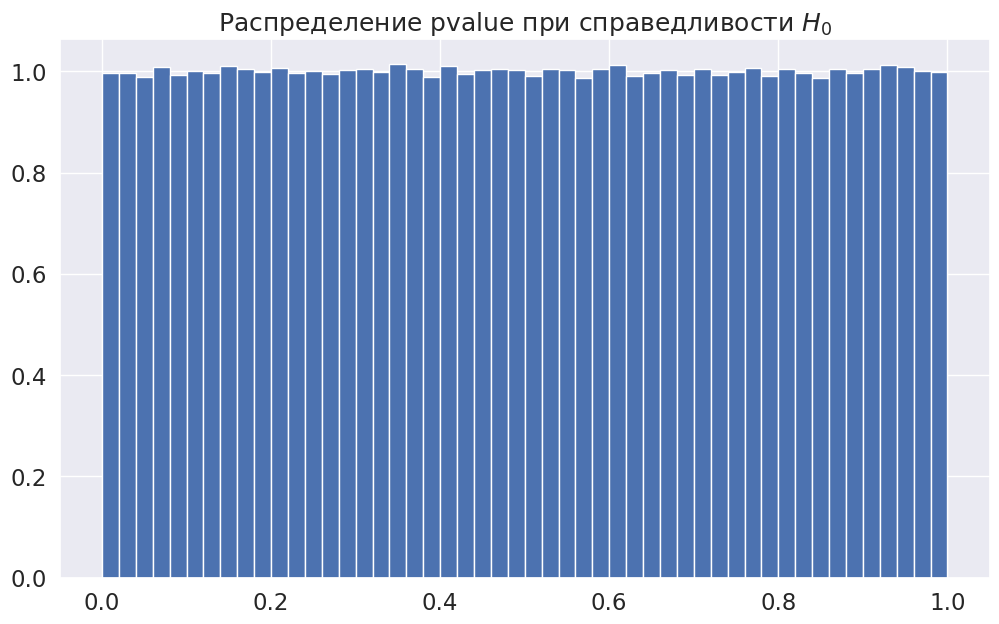

In [7]:
plt.figure(figsize=(12, 7))
plt.hist(p_values, density=True, bins=50)
plt.title('Распределение pvalue при справедливости $H_0$')
plt.show()

**Вывод:** При проверке распределения p-value при справедливости нулевой гипотезы ($\theta = 0$), мы наблюдаем, что p-value распределены равномерно на отрезке от 0 до 1. Это подтверждает корректность работы критерия при справедливости нулевой гипотезы, так как вероятность ошибки первого рода равна уровню значимости $\alpha$.

Как мы говорили, критерий не меняется при рассмотрении сложной основной гипотезы

$\mathsf{H}_0\colon\ \theta \leqslant 0\ \ vs.\ \ \mathsf{H}_1\colon\ \theta\ > 0$

Посмотрим, что будет при непограничном значении $\theta$ из новой нулевой гипотезы.
Для этого сгенерируйте выборки со сдвигом $< 0$ и снова постройте распределение pvalue.

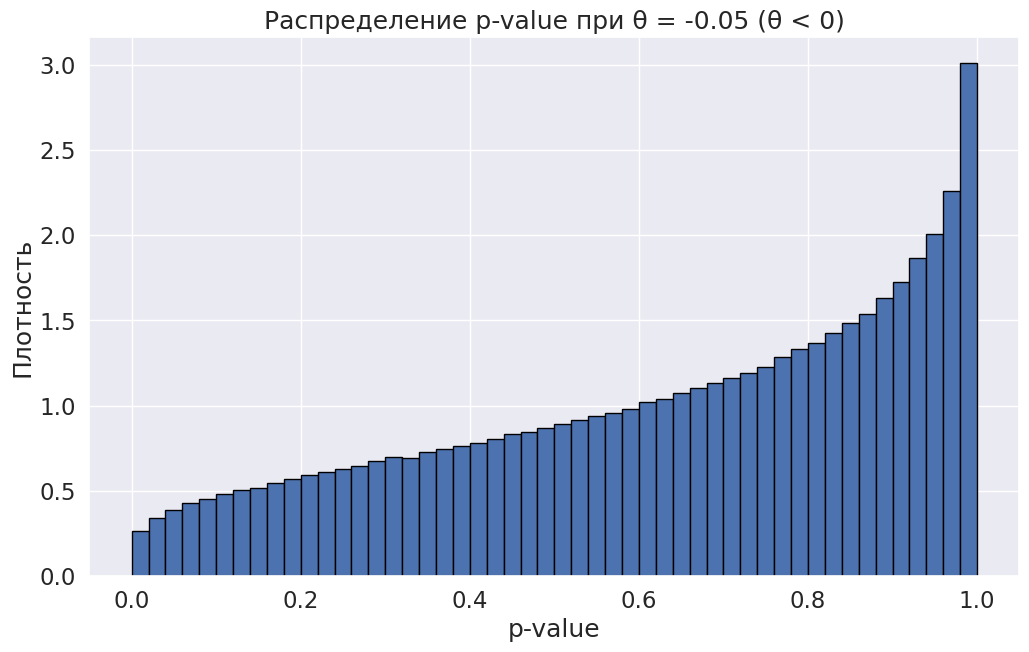

In [20]:
theta = -0.05
alpha = 0.05

samples = np.random.normal(loc=theta, scale=1, size=(sample_count, sample_size))

z_values = np.sqrt(sample_size) * (samples.mean(axis=1) - 0)

p_values = 1 - sps.norm.cdf(z_values)

plt.figure(figsize=(12, 7))
plt.hist(p_values, bins=50, density=True, edgecolor='black')
plt.title('Распределение p-value при θ = -0.05 (θ < 0)')
plt.xlabel('p-value')
plt.ylabel('Плотность')
plt.show()

**Вывод:**
При генерации выборок с параметром $\theta = 1$, то есть из альтернативы $\mathsf{H}_1\colon\ \theta > 0$, распределение p-value становится смещенным в сторону нуля. Это свидетельствует о том, что критерий часто отвергает нулевую гипотезу при таких значениях $\theta$. Доля случаев, когда p-value меньше 0.05, соответствует мощности критерия при данном значении $\theta$.


Теперь посмотрим то же самое при альтернативе. Как мы видим, в большинстве случаев основная гипотеза отвергается. Доля случаев, в которых p-value меньше 0.05, является оценкой мощности критерия при данном распределении из альтернативы.

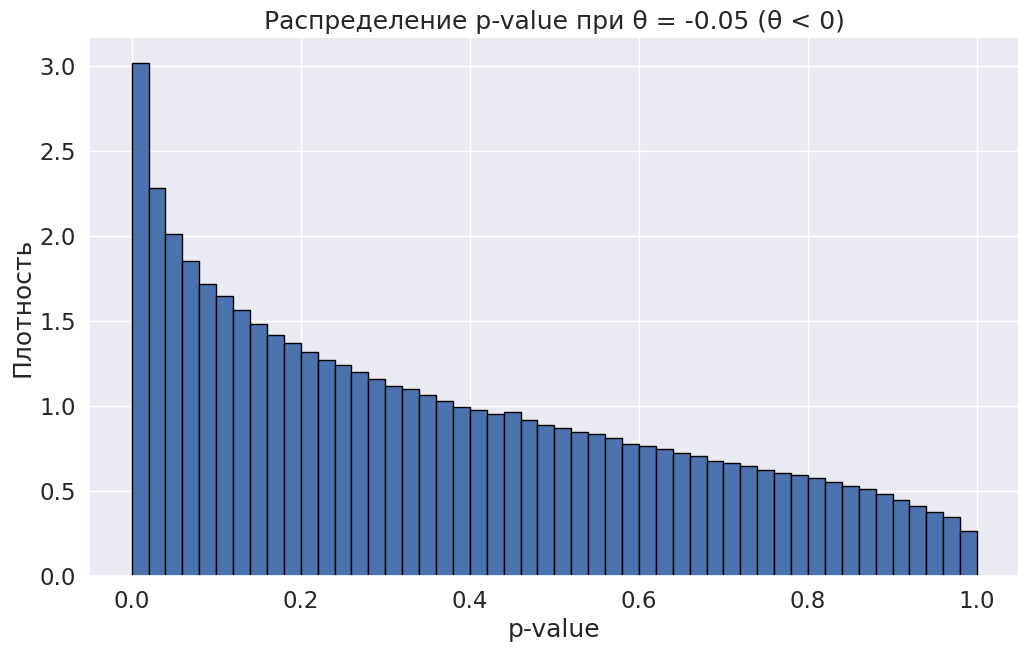

In [24]:
theta = -0.05
alpha = 0.05

samples = np.random.normal(loc=theta, scale=1, size=(sample_count, sample_size))

z_values = np.sqrt(sample_size) * (samples.mean(axis=1) - 0)

p_values = sps.norm.cdf(z_values)

plt.figure(figsize=(12, 7))
plt.hist(p_values, bins=50, density=True, edgecolor='black')
plt.title('Распределение p-value при θ = -0.05 (θ < 0)')
plt.xlabel('p-value')
plt.ylabel('Плотность')
plt.show()

**Вывод**:

Какой рассмотренной величине соответствует доля pvalue, меньших $\alpha = 0.05$?

**Ответ**: